# IMPORTS

In [ ]:
# libraries for loading files
#!pip -q install gdown
import gdown
import zipfile
from google.colab import files

# basic libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import copy
import os
from pathlib import Path
from collections import Counter
from datetime import datetime

# machine learning
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset #for easy dataset management
from PIL import Image
import torchvision.transforms as transforms
import torchvision.models as models

# train split support and sklearn
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, accuracy_score

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [ ]:
def set_seed(seed=42):
    """
    Function to random seeds for reproducibility.
    """
    np.random.seed(seed)

    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


set_seed()

# PROBLEM PARAMETERS

The glass sheet counting challenge presents a predictive problem that has both classification and regression components.

For the ****classification or categorical component****, I observed that glass sheet stacks of certain sizes show specific visual patterns/features in the images that can be treated as categorical. However, given the nature of the images, these patterns can be noisy and sometimes missing.

In contrast, the ****regression component**** is less noisy, as it requires information on the relative length/dimension of the glass sheets within the image. These relative dimensions are proportional to the number of sheets in the image.

I also want to highlight that the number of sheets is discrete and can be expressed as categorical classes.

Using the minimum number ($\mathrm{MIN\_NUM}$) and maximum number ($\mathrm{MAX\_NUM}$) of sheets in the glass stack, the possible number of classes can be determined as follows:

$$\mathrm{NUM\_CLASSES} = \mathrm{MAX\_NUM} - \mathrm{MIN\_NUM} + 1 $$

The provided sheet thickness can also be helpful when calibrating the model parameters, especially for feature engineering or augmentation.

To account for changing lighting conditions, I have utilized data augmentation.

****Assumptions:****

Based on the training data and the problem, I have highlighted below some of the key assumptions that I took into consideration:

*   Assuming all images have the same dimensions.

*   Assuming the glass sheets in the stack have similar alignment or placement as they are in the training data.


In [ ]:
EXPECTED_MAE = 0.5

#defining minimum and maximum number of sheets to compute number of classes
#for model
MIN_NUM = 20  # minimum number
MAX_NUM = 35  # maximum number

#Number of classes needed
#Assuming the minimum and maximum numbers are inclusive
NUM_CLASSES = MAX_NUM - MIN_NUM + 1

# Sheet width deviation
TOLERANCE = 0.05

#storing parameters in one list
META = [MIN_NUM, MAX_NUM, NUM_CLASSES, TOLERANCE]


# INGESTION

For data ingestion, the data is automatically downloaded from a Google Drive with ****"Anyone with Link"**** access. This data is curated and placed into pandas data frames. These data frames are used for the training split and loaded into custom dataset modules based on PyTorch.


## Data Download

In [ ]:
#Using gdown to download the project files
BASE_DIR = Path.cwd()

zip_path = BASE_DIR / "Counting_Glass_Sheets.zip"

data_dir = BASE_DIR / "Counting_Glass_Sheets"

data_url = "" # TRAINING DATA LINK

#check if file exists before download
if not data_dir.exists():
    gdown.download(data_url, str(zip_path), fuzzy=True, quiet=False)
else:
    print("File already exists!")


File already exists!


In [ ]:
import socket
import requests

print("DNS:", socket.gethostbyname("drive.google.com"))

r = requests.get("https://www.google.com", timeout=10)
print("HTTP:", r.status_code)

DNS: 74.125.139.102
HTTP: 200


In [ ]:
#unzipping the file
!unzip -o -q "./Counting_Glass_Sheets.zip" -d "./Counting_Glass_Sheets"

In [ ]:
#path to the image folders in current session
path= str(Path.cwd()/"Counting_Glass_Sheets")+'/'

#checking to confirm the files are downloaded correctly and
#the folders are available
content=os.listdir(path)

print('Data Path:', path)
print('Content:',content)

if  not all(item in content  for item in ['labels.csv', 'test', 'train']):
    raise Exception('Training Data Missing!')

Data Path: /kaggle/working/Counting_Glass_Sheets/
Content: ['test', 'labels.csv', 'train']


## Data Paths

In [ ]:
# data paths
train_path = path + 'train'
test_path =  path + 'test'

#label path
label_path =  path + 'labels.csv'

print(f"""
Train Data Path: {train_path}

Test Data Path: {test_path}

Label Data Path: {label_path}
""")


Train Data Path: /kaggle/working/Counting_Glass_Sheets/train

Test Data Path: /kaggle/working/Counting_Glass_Sheets/test

Label Data Path: /kaggle/working/Counting_Glass_Sheets/labels.csv



## Labels

In [ ]:
#extracting the labels data from the csv file into data frame
labels_df= pd.read_csv(label_path)
labels_df.head()

,img_number,num_sheets
0,0,33
1,1,35
2,2,35
3,3,28
4,4,31


## Loading Image Paths

In [ ]:
# checking train and test directories, and loading the image file paths.

#for train images
train_img_paths = [ _file for _file in os.listdir(train_path)
                    if os.path.isfile(os.path.join(train_path, _file))
                  ]

#for test images
test_img_paths = [ _file for _file in os.listdir(test_path)
                    if os.path.isfile(os.path.join(test_path, _file))
                  ]

print(f"""
Train Images: {len(train_img_paths)}
Test Images: {len(test_img_paths)}
""")


Train Images: 200
Test Images: 50



## Data Curation

To ensure that all images without labels in the "labels.csv" file are placed in the test folder, I implemented a data curation function that processes the images and organizes them into Pandas data frames. The function detects any images without labels and transfers them to the test folder.

**Note:** I implemented this step to ensure the robustness of the pipeline, such that all samples used in training have labels because my machine learning approach will be supervised.

In [ ]:
def curate_data(train_paths, test_paths, labels_df, logging=False):
    """
    Function to confirm whether all images in train set are in labels.csv, and
    allocate images to appropriate set

    returns:
         train_df:  Pandas dataframe with train image ids, paths and labels
         test_df:  Pandas dataframe with test image ids, paths and labels
    """

    valid_train_paths = [] # image file names with extensions
    valid_test_paths = []

    valid_train_ids = [] # image numbers
    valid_test_ids = []

    extra_train = 0 # extra train images without labels
    extra_test = 0 # extra test images with labels


    # getting the available image numbers with labels
    img_nums = labels_df[['img_number']].to_numpy().flatten()

    #checking and allocating train images in not labels.csv
    if logging:
        print("Available image labels: ",img_nums)
    for img_path in train_paths:

       try:
          name = Path(img_path).stem  #file name
          img_number = int(name) # getting number as the file name
       except:
            continue
       if img_number in img_nums:
             # allocating to train set

             valid_train_ids.append(img_number)
             valid_train_paths.append(img_path)
       else:

             if(logging):
                print("train image label not found! image:", img_number)
                print("transfering image to test set")

             # allocating to test set
             valid_test_paths.append(img_path)
             valid_test_ids.append(img_number)

             extra_train+=1

    #checking and allocating test images with labels.csv
    for img_path in test_paths:
       try:
          name = Path(img_path).stem  #file name
          img_number = int(name) # getting number as the file name
       except:
            continue

       if img_number in img_nums:
             # allocating to train set
             if(logging):
                print("test image label found! image:", img_number)
                print("transfering image to train set")

             valid_train_paths.append(img_path)
             valid_train_ids.append(img_number)

             extra_test+=1
       else:
             # allocating to test set
             valid_test_paths.append(img_path)
             valid_test_ids.append(img_number)

    #preparing data frame for dataloader
    train_df = pd.DataFrame({
        'img_number': valid_train_ids,
        'img_path': valid_train_paths,
    })


    train_df = train_df.merge(
        labels_df[['img_number', 'num_sheets']],
        on='img_number',
        how='left'
    )
    #test data frame
    test_df = pd.DataFrame({
       'img_number': valid_test_ids,
       'img_path': valid_test_paths,
    })


    print(f"""

    #######################
    ORIGINAL TRAIN IMAGES: {len(train_paths)}
    ORIGINAL TEST IMAGES: {len(test_paths)}
    #######################

    EXTRA TRAIN IMAGES: {extra_train}
    EXTRA TEST IMAGES: {extra_test}
    #######################

    VALID TRAIN IMAGES: {len(valid_train_paths)}
    VALID TEST IMAGES: {len(valid_test_paths)}
    #######################

    """)
    return train_df, test_df

In [ ]:
#Implementing data curation
train_df, test_df = curate_data(train_img_paths, test_img_paths,labels_df)



    #######################
    ORIGINAL TRAIN IMAGES: 200
    ORIGINAL TEST IMAGES: 50
    #######################

    EXTRA TRAIN IMAGES: 0
    EXTRA TEST IMAGES: 0
    #######################

    VALID TRAIN IMAGES: 200
    VALID TEST IMAGES: 50
    #######################

    


In [ ]:
#checking the training data frame
train_df.head()

,img_number,img_path,num_sheets
0,35,035.jpg,28
1,25,025.jpg,29
2,59,059.jpg,26
3,190,190.jpg,21
4,166,166.jpg,24


In [ ]:
#checking the test data frame
test_df.head()

,img_number,img_path
0,208,208.jpg
1,200,200.jpg
2,237,237.jpg
3,225,225.jpg
4,214,214.jpg


## Train and Validation Split

I also used the training dataframe to carry out a train-test split in order to generate training and validation data. The validation data is intended to provide an indication of how well the model is generalizing.


In [ ]:
#implementing train-test split
train_set_df, valid_set_df = train_test_split(
                              train_df,
                              test_size=0.3,
                              random_state=42,
                              stratify=train_df['num_sheets']
                              )
print(f"""
Train set count:
{train_set_df.count()}

Validation set count:
{valid_set_df.count()}
""")


Train set count:
img_number    140
img_path      140
num_sheets    140
dtype: int64

Validation set count:
img_number    60
img_path      60
num_sheets    60
dtype: int64



## Data Exploration

I also carried out data exploration to understand the distribution of the training data and how it could affect the learning signal. The results show that the training data is fairly balanced. I also implemented some trivial baselines, including a random predictor and a majority-class baseline. Their results show that the trivial baselines are not very predictive.


### Training Data Distribution

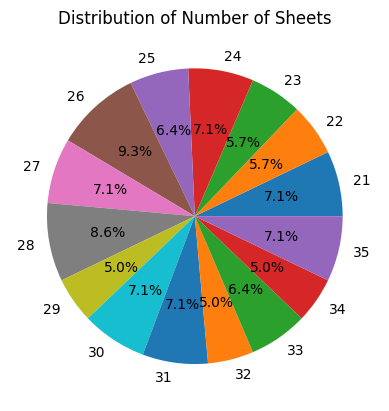

In [ ]:
# computing the class counts
counts = train_set_df["num_sheets"].value_counts().sort_index()

#drawing pie of the number of sheets
plt.pie(
    counts.values,
    labels=counts.index,
     autopct="%1.1f%%"
)
plt.title("Distribution of Number of Sheets")
plt.show()

### Random Baseline

In [ ]:
# Random Uniform Baseline
valid_labels = train_set_df['num_sheets']

classes =  [MIN_NUM+i for i in  range(NUM_CLASSES)]

#making random choices for the number of class sheets
random_predictions = np.random.choice(
    classes,
    size=len(valid_labels)
)

#computing the performance of random baseline
random_mae = mean_absolute_error(valid_labels, random_predictions)
random_accuracy = accuracy_score(valid_labels, random_predictions)

print(f"Random Baseline MAE: {random_mae:.3f}")
print(f"Random Baseline Accuracy: {random_accuracy:.3f}")

Random Baseline MAE: 4.671
Random Baseline Accuracy: 0.100


### Majority Class Baseline

In [ ]:
#Majority Class Baseline
counts = Counter(train_set_df['num_sheets'].to_numpy())

#computing most common class
majority_class = counts.most_common(1)[0][0]

#making predictions based on majority class
majority_predictions = np.full(len(valid_labels), majority_class)

mae = mean_absolute_error(valid_labels, majority_predictions)
accuracy = accuracy_score(valid_labels, majority_predictions)

print(f"Majority Baseline MAE: {mae:.4f}")
print(f"Majority Baseline Accuracy: {accuracy:.4f}")

Majority Baseline MAE: 3.7929
Majority Baseline Accuracy: 0.0929


## Custom Dataset

I implemented a custom dataset class to handle the ingestion of data from the dataframe and prepare it for input into the model. The custom dataset class also generates engineered features for training.

In [ ]:
class ImageDataset(Dataset):
  """
  Custom dataset for loading sheets of images into the data loader
  """
  def __init__(self,
               root,
               dataframe,
               meta,
               transform =None,
               feature_func=None,
               include_spectral=False,
               ):

     super(ImageDataset,self).__init__()

     #path to the image data folder
     self.root = root

     #loading data from the data frame
     self.images = dataframe['img_number'].to_numpy()
     self.image_paths= dataframe['img_path'].to_numpy()  # image file name with extension

     #loading problem meta data including number of classes to predict
     self.meta=meta

     #storing bool option to determine whether to include spectral scores
     #from the spectral baseline
     self.include_spectral=include_spectral

     if 'num_sheets' in dataframe.columns:
        self.labels = dataframe['num_sheets'].to_numpy()
     else:
        self.labels = []

     #PyTorch vision transform function to augment the data
     self.transform = transform

     #function to generate engineered features for the data
     self.feature_func=feature_func

  def __len__(self):
     # return dataset size
     return len(self.images)

  def __getitem__(self,index):
         #loading meta parameters
         MIN_NUM, MAX_NUM, NUM_CLASSES, TOLERANCE = self.meta

         #image file name /number
         img_number = self.images[index]

         label_org = None #original label

         #computing the target label for training the model
         if(len(self.labels) != 0 and index < len(self.labels)):
               # subtracting the minimum num of sheets
               # to obtain targets compatible with the pytorch cross entropy loss
               label_org = self.labels[index]
               label = label_org  - MIN_NUM

               #clipping the keep the number of sheets in the max range
               label = np.clip(
                   label,
                   a_min=0,
                   a_max=MAX_NUM - MIN_NUM)
               label = torch.tensor(label, dtype=torch.long)
         else:
               label = torch.tensor(-1, dtype=torch.long)

         #making the full image file path
         image_path = self.root +'/'+ self.image_paths[index]

         #
         image = Image.open(image_path)

         if self.transform:
               image = self.transform(image)

         #generating additional features
         features = torch.zeros(7 + NUM_CLASSES*2) if self.include_spectral == True else torch.zeros(7)
         if(self.feature_func != None):
                 left,right,center, width, scores = self.feature_func(
                                                  image,label_org,
                                                  meta=self.meta,
                                                  include_spectral = self.include_spectral
                                                  )

                 features = torch.tensor([
                                      left[0],
                                      left[1],
                                      right[0],
                                      right[1],
                                      center[0],
                                      center[1],
                                      width
                                ],dtype=torch.float32)
                 if(len(scores)>0):
                        scores = torch.tensor(scores, dtype=torch.float32)

                        features = torch.cat([features, scores])

         #additional meta data for image sample
         meta = {
             'img_number' : img_number
         }

         return image, label, features, meta

### Transform

To account for changing lighting conditions, I used PyTorch transform functions to augment the images using zoom effects, color effects, and translation effects. These augmentations made the learning task more challenging, enabling the model to generalize better.

**Note:** These augmentations are mainly implemented for the training data only. The intention is for the validation and test tasks to be simpler for the model. It was therefore important that the augmentations were kept to a minimum to avoid a strong distribution shift between the datasets.

In [ ]:
# transform for the training set
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),

    transforms.RandomRotation(
        degrees=3,
        fill=(255,255,255)
    ),

    transforms.RandomAffine(
        degrees=0,
        scale=(0.9, 1.1),   #adding zoom effect between 90% and 110%
        fill=(255,255,255)
    ),

    transforms.ColorJitter(
        brightness=0.15,    #Augmentating the samples with brightness and contrast
        contrast=0.15
    ),
    transforms.ToTensor()
])

# transform for the validation set
eval_transform = transforms.Compose([
    transforms.ToTensor()
])

### Feature Engineering

I generated engineered features using image processing and spectral analysis techniques. I used image processing to filter out the background and turn it into a single color (red) before the estimated relative pixel width of the glass stack and its relative positions were computed. It is worth noting that this image processing relies on the assumption that the background will always be brighter than the glass stack within the image.

Using knowledge from my MSc thesis on mass spectra, I also analysed the images as spectra in order to determine how well a given number of sheets fits the image's spectral representation. This technique involved extracting a target pixel row and treating it as a spectrum. The theoretical peak positions based on the actual number of sheets were then used to determine how well the class fits the spectrum using information about the spacing and variance of observed peaks and predicted positions.

This technique created a form of spectral model that is predictive of the number of sheets using the resulting score. The score is designed such that the lower the value, the higher the chance that the image fits the class. However, the images are noisy and, with added augmentation, the spectral model's predictions are also noisy and are sometimes inaccurate. I therefore made the choice to use the predictions of the spectral model to condition my main model. For my approach, the spectral model acts as a feature generator.

In [ ]:
def generate_additional_features(image,label, meta,include_spectral=False,visualize=False, logging=False):
        '''
        Function to generate additional features from the images.

        Note: I included the labels here only for logging, but not for feature generation.

        Returns:
              [left_x, left_y] :  Estimated left boundary point.
              [right_x, right_y] :  Estimated right boundary point.
              [center_x, center_y] :  Estimated  right center point.
              pixel_width:   Estimated minimum width in pixels of sheet stack based on image

        '''
        #loading meta parameters
        MIN_NUM, MAX_NUM, NUM_CLASSES, TOLERANCE  = meta

        _, HEIGHT, WIDTH = image.shape
        #loading image data
        num_sheets = label.item()   if label != None else None

        if logging == True:
            print("Image shape:", image.shape)
            print("Label:", num_sheets)

        #structuring the data: [C,H,W] -> [H,W,C]
        img = image.permute(1, 2, 0).clone()
        img_org = image.permute(1, 2, 0).clone()

        #average RGB value for each pixel
        avg_color = img.mean(dim=2)

        #creating masks to select pixels whose average color
        #is within thresholds to detect background

        mask = avg_color > 0.25  # detecting bright background

        mask2 = avg_color < 0.01  # detecting shadows

        #turning selected pixels to red
        img[mask] = torch.tensor([1.0, 0.0, 0.0])

        img[mask2] = torch.tensor([1.0, 0.0, 0.0])


        #mask for pure red pixels
        red_mask = (
            (img[:, :, 0] == 1.0) &
            (img[:, :, 1] == 0.0) &
            (img[:, :, 2] == 0.0)
        )

        #computing the average pixel width:

        #mask for finding non red pixels
        non_red_mask = ~red_mask

        H, W = non_red_mask.shape

        #lists to store the minimum x positions
        row_mins = []
        row_maxs = []

        #list to  store the valid pixel heights that contain target pixels
        valid_rows = []

        #looping through the image pixel rows
        #to compute the minimum and maximum x position with non red pixels
        #that indicate the location of the glass stack
        for y in range(H):

            x_positions = torch.where(non_red_mask[y])[0]

            #skip rows with no non-red pixels
            if x_positions.numel() == 0:
                continue

            row_mins.append(x_positions.min().item())
            row_maxs.append(x_positions.max().item())

            valid_rows.append(y)

        #converting to tensors
        row_mins = torch.tensor(row_mins, dtype=torch.float32)
        row_maxs = torch.tensor(row_maxs, dtype=torch.float32)

        valid_rows = torch.tensor(valid_rows)

        average_y = valid_rows.float().mean().item()

        #calculating boundary points in pixels
        average_min_x = row_mins.mean().item()
        average_max_x = row_maxs.mean().item()

        # point cordinates
        min_x_px = int(round(average_min_x))
        max_x_px = int(round(average_max_x))
        y_px = int(round(average_y))

        #center point
        center_x_px = int(round((min_x_px + max_x_px) / 2))

        #stack width in pixels
        width_px = abs(max_x_px - min_x_px)

        if logging == True:
                print("Left point  :", (min_x_px, y_px))
                print("Right point :", (max_x_px, y_px))
                print("Center      :", (center_x_px, y_px))
                print("Width       :", width_px, "pixels")

        # plot to visualize estimate points
        if visualize == True:

              plt.figure(figsize=(8, 10))
              plt.imshow(img_org)

              #left averaged point
              plt.scatter(
                  min_x_px,
                  average_y,
                  s=30,
                  color='yellow',
                  linewidths=1
              )

              #right averaged point
              plt.scatter(
                  max_x_px,
                  average_y,
                  s=30,
                  color='yellow',
                  linewidths=1
              )

              #center point
              plt.scatter(
                  center_x_px,
                  average_y,
                  s=30,
                  color='yellow'
              )

              plt.title(f"Sheets: {label.item()} \n With Feature Points in Yellow")
              plt.axis("off")
              plt.show()

        #computing the spectral score and features
        spectral_features = []
        if include_spectral == True:
            '''
            If include spectral is True, then spectral scores are
            computed by converting a selected pixel row into a spectrum, and
            determining how well the spectrum fits the expected
            sheet positions based on target number of sheets or class.
            The lower the score, the higher the probability that the
            expected number of sheets fits the spectra. In additional to the
            score, the number of peaks that fit the class is also generated.
            '''

            #pixel row position for generating the spectral features
            row_idx = int(average_y)

            #getting the selected row data
            row = img_org[row_idx, :, :]

            #pixel colors for the row
            avg_color_row =  row.mean(dim=1)
            #accessing the pixel positions
            pixel_position = torch.arange(len(avg_color_row))

            left = min_x_px
            right = max_x_px

            #computing the row pixel data with boundary
            #to ignore background noise
            avg_color_row= avg_color_row[left:right + 1]
            pixel_position = pixel_position[left:right + 1]


            #normalizing the color/intensities for the spectrum
            mean = avg_color_row.mean()
            std = avg_color_row.std()
            #avg_color_row = (avg_color_row - mean) / std


            #preparing data for sampling the spectrum
            class_index = np.arange(NUM_CLASSES) #index of the class

            #class labels / number of sheets
            num_labels = class_index + MIN_NUM

            #matrix containing expected positions for every possible number of sheets
            pos_matrix = np.full((NUM_CLASSES, MAX_NUM), -1.0)

            for i in class_index:
                num = num_labels[i]
                spacing = width_px / num
                pos_matrix[i, :num] = [
                    left + a * spacing
                    for a in range(num)
                ]

            #array to store the scores
            class_scores = np.zeros(NUM_CLASSES)
            num_peaks = []

            #variable to control how peaks are accepted
            delta = 0.2

            #min number of peak matches to consider as a strong signal
            min_matches = 5

            #list to store the spacing of the sheets estimated
            spacing_list=[]

            #variable to determine window around the class divisions
            #in the spectrum
            wd = 0.6

            #looping for each class/number of sheets to compute
            #spectral properties/score.
            for i in class_index:
                num = num_labels[i]
                spacing = width_px / num
                dt = int(wd* spacing)

                min_pos = []

                #looping to sample peaks
                for p in pos_matrix[i, :num]:
                    if p == -1:
                        continue

                    #original-image pixel coordinate
                    p = int(round(p))

                    #converting to coordinate of bounded window (avg_color_row)
                    p_crop = p - left

                    #window boundaries around the class division
                    start = max(0, p_crop - dt)
                    end = min(len(avg_color_row), p_crop + dt)

                    #sampling the peaks within the window
                    data = avg_color_row[start:end]
                    if len(data) == 0:
                        continue

                    #minimum position in the cropped window
                    min_idx = torch.argmin(data).item()

                    #converting the  minimum position to image coordinate
                    min_pos_full = left + start + min_idx

                    #difference between expected and detected position
                    distance = abs(min_pos_full - p)

                    #checking if distance is limits before accepting peak
                    if distance <= delta * spacing:
                        min_pos.append(min_pos_full)

                #computing number of peaks detected
                peak_num = len(min_pos)

                num_peaks.append(peak_num)

                #checking if minimum of peak matches is met and
                #computing appropriate score
                if len(min_pos) < min_matches :
                    score = spacing*10  #this is treated as a bad match
                    spacing_list.append(score)
                else:
                    #score is based on how many peaks consecutively
                    #have mean spacing close to the class spacing

                    #computing the mean consecutive spacing
                    diff = np.diff(min_pos).mean()

                    #computing the spacing variance of detected peaks
                    std = np.diff(min_pos).std()

                    spacing_list.append(diff)

                    #the score is influenced by the difference between
                    #estimated spacing error and spacing variance

                    eps=1e-8  #for stability

                    spacing_error = abs(diff - spacing) / (spacing + 1e-8)

                    spacing_variability = std / (diff + 1e-8)

                    score = spacing_error + spacing_variability

                #storing the class score
                class_scores[i] = score

            #normalizing the computed spectral scores and properties
            scores = torch.tensor(class_scores, dtype=torch.float32)

            scores_norm = F.normalize(scores, p=2, dim=0)
            for i in class_index:
                spectral_features.extend([
                    scores_norm[i].item(),
                    num_peaks[i] / MAX_NUM
                ])

            #visualizing results
            if logging == True:
                  best_idx = np.argmin(class_scores)
                  predicted_num_sheets = num_labels[best_idx]

                  print(f"\nClass scores [True Label = {num_sheets}]:")
                  for i, score in enumerate(class_scores):
                      print(f"{num_labels[i]} sheets: {score:.4f}  spacing: {spacing_list[i]:.2f} num: {num_peaks[i]}")

                  print(f"\nPredicted: {predicted_num_sheets} sheets "
                        f"(true: {num_sheets}), score={class_scores[best_idx]:.4f}")

            if visualize == True:
                  plt.figure(figsize=(18, 5))
                  #spectrum plot
                  plt.plot(
                      np.arange(len(avg_color_row)) + left,
                      avg_color_row.cpu().numpy()
                  )

                  # expected positions for estimated class
                  for p in pos_matrix[i, :num_labels[i]]:
                      plt.axvline(p, linestyle="--", alpha=1.0, color='red')

                  plt.title(
                      f"Winner: {predicted_num_sheets} sheets | "
                      f"score={class_scores[i]:.4f}"
                  )

                  plt.xlabel("Full-image x position")
                  plt.ylabel("Average color")
                  plt.grid(alpha=0.5)

                  plt.show()


        #returning the normalized engineered properities
        return  ([min_x_px/WIDTH, y_px/HEIGHT],
                 [max_x_px/WIDTH, y_px/HEIGHT],
                 [center_x_px/WIDTH, y_px/HEIGHT],
                 width_px/WIDTH,
                 spectral_features
                )


sample_index: 87
Image shape: torch.Size([3, 768, 576])
Label: 28
Left point  : (130, 384)
Right point : (482, 384)
Center      : (306, 384)
Width       : 352 pixels


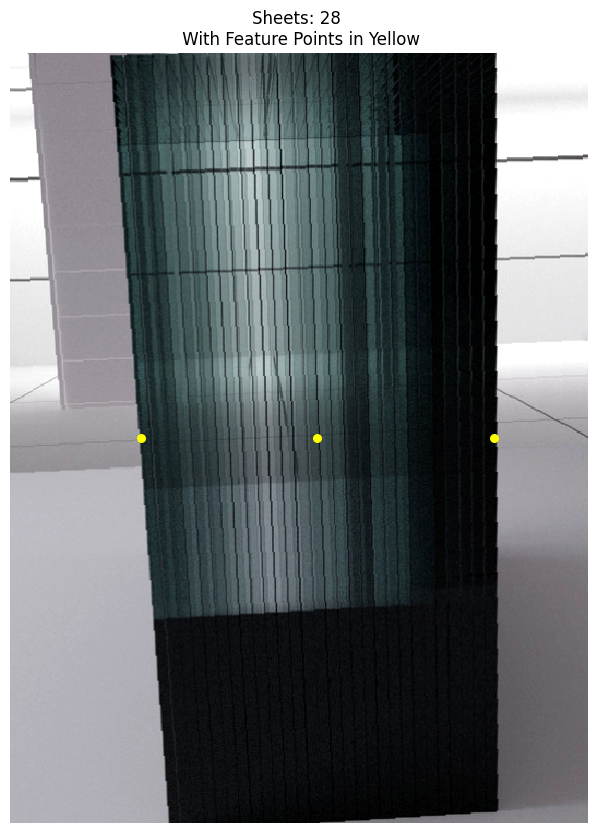


Class scores [True Label = 28]:
20 sheets: 1.2046  spacing: 32.90 num: 11
21 sheets: 1.3688  spacing: 31.90 num: 11
22 sheets: 1.5600  spacing: 31.90 num: 11
23 sheets: 1.9541  spacing: 35.44 num: 10
24 sheets: 1.7419  spacing: 29.00 num: 12
25 sheets: 2.3366  spacing: 33.00 num: 9
26 sheets: 2.5589  spacing: 32.29 num: 8
27 sheets: 4.7582  spacing: 56.00 num: 7
28 sheets: 0.7503  spacing: 16.00 num: 22
29 sheets: 2.4748  spacing: 24.92 num: 13
30 sheets: 3.4737  spacing: 41.12 num: 9
31 sheets: 2.8085  spacing: 32.90 num: 11
32 sheets: 2.3204  spacing: 27.42 num: 13
33 sheets: 2.2647  spacing: 27.42 num: 13
34 sheets: 1.9530  spacing: 23.50 num: 15
35 sheets: 2.1127  spacing: 25.31 num: 14

Predicted: 28 sheets (true: 28), score=0.7503


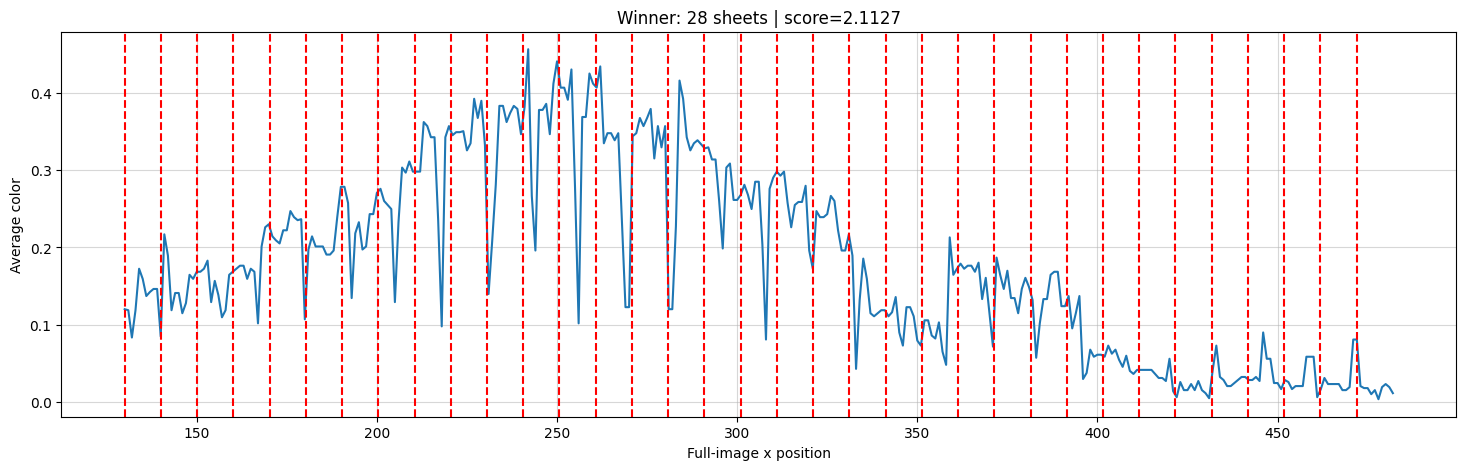

In [ ]:
#TESTING FEATURE GENERATION:

#sampling random data point
idx = np.random.randint(low=0,   high=len(train_set_df))

print("sample_index:",idx)
df = train_set_df

#sample image
sample = df.iloc[idx]

root = train_path

#image path
image_path = root +'/'+ str(sample['img_path'])

image = Image.open(image_path).convert("RGB")

label = sample['num_sheets']

#tranforming image as same as in training
if train_transform:
              image = train_transform(image)

output =generate_additional_features(
                          image,
                          label,
                          meta=META,
                          include_spectral=True ,
                          visualize=True,
                          logging=True
                          )

#### Spectral Baseline

Based on the spectral baseline results, the spectral baseline performs better than the majority-class and random baselines. The results indicate that the spectral baseline has a strong predictive signal and can provide meaningful complementary information for training the main model.

In [ ]:
#analysis of the spectral model/baseline

count =  len(valid_set_df) #total number samples
df = valid_set_df

class_index = np.arange(NUM_CLASSES) #index of the class

#class labels / number of sheets
num_labels = class_index + MIN_NUM

pred_accuracy = 0
pred_mae = 0

for idx in range(count):
    #sample image
    sample = df.iloc[idx]

    root = train_path

    #image path
    image_path = root +'/'+ str(sample['img_path'])

    image = Image.open(image_path).convert("RGB")

    label = sample['num_sheets']

    #tranforming image as same as in training
    if train_transform:
              image = eval_transform(image)

    output = generate_additional_features(
                           image,
                           label,
                           meta=META,
                           include_spectral=True ,
                           visualize=False,
                           logging=False
                           )

    left, right, center, width, spectra_values = output

    class_scores = [spectra_values[i*2] for i in class_index]

    best_idx = np.argmin(class_scores)
    pred_num_sheets = num_labels[best_idx]

    #print(f"Predicted Label: {pred_num_sheets} [True Value = {label}]")
    pred_accuracy += 1 if pred_num_sheets == label else 0
    pred_mae += abs(pred_num_sheets - label)

accuracy = pred_accuracy / count
mae = pred_mae / count

print(f"""
#### SPECTRAL BASELINE ANALYSIS ###
Samples: {count}
Accuracy: {accuracy:.4f}
MAE: {mae:.4f}
""")


#### SPECTRAL BASELINE ANALYSIS ###
Samples: 60
Accuracy: 0.6000
MAE: 2.2000



### Dataset Instances

In [ ]:
#creating the datasets for training, validation and testing

train_dataset = ImageDataset(root=train_path,
                             dataframe = train_set_df,
                             meta=META,
                             transform=train_transform,
                             include_spectral=True,
                             feature_func=generate_additional_features
                             )

valid_dataset = ImageDataset(root=train_path,
                             dataframe = valid_set_df,
                             meta=META,
                             transform=eval_transform,
                             include_spectral=True,
                             feature_func=generate_additional_features
                             )

test_dataset = ImageDataset(root=test_path,
                            dataframe = test_df,
                            meta=META,
                            transform=eval_transform,
                            include_spectral=True,
                            feature_func=generate_additional_features
                            )

# MODELLING

My model is a custom Convolutional Neural Network (CNN) consisting of a CNN component that filters the images using learned features to produce a low-dimensional representation, as well as a classifier head and regression head. Both heads are conditioned on the CNN output, as well as a set of engineered features from the image. The engineered features include the average normalized relative pixel width of the glass sheet stack, normalized average pixel positions for the left, right, and center of the glass stack, as well as spectral properties that show how well a given class fits the image.

## Hyperparameters

I also setup a number of hyperparameters to tune and control the model's training.

In [ ]:
# Hyperparameters
learning_rate = 3e-4
weight_decay= 1e-4
batch_size = 16
num_epochs = 650
num_classes= NUM_CLASSES
hidden_dim = 256
dropout = 0.0
checkpoint_interval = 50 #epoch interval to evaluate and save checkpoints

#training loss configs:
lambda_huber  = 2.0
lambda_ce = 0.25
lambd_mae = 0.5
lambda_consist = 2.0

#getting the image input dimension assuming all images have the same dimension
img,_,_,_ = train_dataset[0]

print("Image Shape", img.shape)

input_dim =  img.shape[0]*img.shape[1]*img.shape[2]

in_channels = img.shape[0]

print("Input dimension:",input_dim)
print("Input Channels:",in_channels)

Image Shape torch.Size([3, 768, 576])
Input dimension: 1327104
Input Channels: 3


## DataLoaders

In [ ]:
#preparing data loaders to use during training and evaluation
train_loader = DataLoader(dataset= train_dataset, batch_size=batch_size, shuffle=True) # train dataset

valid_loader = DataLoader(dataset= valid_dataset, batch_size=batch_size, shuffle=False) # validation dataset set

test_loader = DataLoader(dataset= test_dataset, batch_size=batch_size, shuffle=False)  # test dataset

## Custom Model

In [ ]:
class CustomCNN(nn.Module):
  def __init__(self,
               in_channels,
               num_classes, #determines dimensionality of components
               dropout = 0.05,
               hidden_dim =  256,
               use_classifier= False, #If True, then the classifier head is added
               use_conditioning = False, #If True then regression is conditioned on classifier head
               use_add_features = False, #If True, then engineered features are added to input
               additional_dim = 0,
               use_classifier_condition=False, #If True, the engineered features are added to classifier's input

              ):
      super(CustomCNN,self).__init__()

      self.dropout = dropout

      #convolution layers
      self.cnn = nn.Sequential(
           nn.Conv2d(in_channels=in_channels, out_channels = 32, kernel_size =(3,3), stride=(1,1), padding=(1,1)),
           nn.BatchNorm2d(32), #for stability
           nn.ReLU(), #for capturing complex patterns

           nn.Conv2d(in_channels=32, out_channels = 32, kernel_size =(3,3), stride=(1,1), padding=(1,1)),
           nn.BatchNorm2d(32),
           nn.ReLU(),

           nn.MaxPool2d(kernel_size =(2,2), stride=(2,2)),  # maxpool = [384, 288]

           nn.Conv2d(in_channels= 32,out_channels= 64, kernel_size =(3,3), stride=(1,1), padding=(1,1)),
           nn.BatchNorm2d(64),
           nn.ReLU(),

           nn.Conv2d(in_channels= 64,out_channels= 64, kernel_size =(3,3), stride=(1,1), padding=(1,1)),
           nn.BatchNorm2d(64),
           nn.ReLU(),

           nn.MaxPool2d(kernel_size =(2,2), stride=(2,2)),   # after maxpool = [192, 144]

           nn.Conv2d(in_channels= 64,out_channels= 128, kernel_size =(3,3), stride=(1,1), padding=(1,1)),
           nn.BatchNorm2d(128),
           nn.ReLU(),

           nn.MaxPool2d(kernel_size =(2,2), stride=(2,2)), # after maxpool = [96, 72]

           nn.Conv2d(in_channels= 128,out_channels= 256, kernel_size =(3,3), stride=(1,1), padding=(1,1)),
           nn.BatchNorm2d(256),
           nn.ReLU(),

           nn.AdaptiveAvgPool2d((4,4))
           )

      self.use_add_features = use_add_features if additional_dim !=0 else False
      self.use_classifier_condition=use_classifier_condition


      self.cnn_dim = 256*4*4 # Based on the CNN output
      self.additional_dim = 0

      if self.use_add_features == True:
                         self.additional_dim  = additional_dim

      self.classifier_add_dim = 0

      if self.use_classifier_condition == True:

             self.classifier_add_dim = self.additional_dim

      #Multi Layer Perceptron to support the classification head
      self.mlp_layer = nn.Sequential(
           nn.Flatten(),  #after convolution, converting to 1 dimensional features
           nn.Linear(self.cnn_dim + self.classifier_add_dim, hidden_dim),
           nn.ReLU(),
           nn.Dropout(self.dropout),
           nn.Linear(hidden_dim , hidden_dim),
           nn.ReLU(),
           nn.Dropout(self.dropout),
      )    if (use_classifier == True) else None

      #classification head
      self.classifier_head = nn.Linear(hidden_dim, num_classes) if use_classifier else None


      self.use_conditioning = use_conditioning

      self.conditioning_dim = 0

      if self.use_conditioning == True and  self.mlp_layer != None:
            self.conditioning_dim = num_classes + self.additional_dim


      # regression head
      self.regression_head = nn.Sequential(
          nn.Flatten(),
          nn.Linear(self.cnn_dim + self.conditioning_dim  , hidden_dim),
          nn.ReLU(),
          nn.Dropout(self.dropout),
          nn.Linear(hidden_dim , hidden_dim),
          nn.ReLU(),
          nn.Dropout(self.dropout),
          nn.Linear(hidden_dim, 1)
      )


  def forward(self,x ,features= None):
       """
       Model's forward pass

       Returns:
            y_reg:  Prediction from regression head
            y_class: Prediction from classification head
       """
       x = self.cnn(x)

       #preparing necessary input for classifier head
       if(self.use_classifier_condition== True and features != None and self.use_add_features):
            x_cls = torch.flatten(x, start_dim=1)

            x_cls = torch.cat(
                [x_cls, features],
                dim=1
            )
       else:
              x_cls=x


       #prediction from classification head
       out_mlp = self.mlp_layer(x_cls) if self.mlp_layer != None else None
       y_class = self.classifier_head(out_mlp) if self.classifier_head != None else None


       #preparing input for the regression head
       if self.conditioning_dim > 0:
                x_reg = torch.flatten(x, start_dim=1)

                class_probs = torch.softmax(y_class, dim=1) if y_class is not None else None

                extras = [x_reg]
                if class_probs is not None:
                    extras.append(class_probs)

                if self.use_add_features and features is not None:
                    extras.append(features)

                x_reg = torch.cat(extras, dim=1)
       else:
                x_reg = torch.flatten(x, start_dim=1)

       #prediction from regression head
       y_reg = self.regression_head(x_reg).squeeze(1)

       return   y_reg, y_class

### Helper Functions

I added these helper functions to support the saving and loading of the model checkpoints.

In [ ]:
def save_checkpoint(path,
                    model,
                    epoch,
                    loss=None ,
                    eval_loss=None,
                    logging=True
                    ):
    """
    Function to save the model checkpoint.
    """

    try:
            model_to_save = model.module if isinstance(model, nn.DataParallel)  else model

            torch.save({
                'epochs': epoch,
                'model_state_dict': model_to_save.state_dict(),
                'loss': loss,
                'eval_loss':eval_loss
            }, path)

            if logging == True:
                print("Checkpoint saving successfully!")
    except Exception as e:
            if logging == True:
                  print(f"Checkpoint saving failed: {e}")
            return 0
    return 1


In [ ]:
def load_checkpoint(path, model, device, load_new_copy = False, logging=True):
      """
      Function to load the model checkpoint.
      """
      try:
              model_to_load = model.module if isinstance(model, nn.DataParallel)  else model

              if load_new_copy == True:
                   model_to_load  = copy.deepcopy(model_to_load)


              checkpoint = torch.load(path, map_location=device)

              model_to_load .load_state_dict(checkpoint['model_state_dict'])

              epochs = checkpoint['epochs'] if 'epochs' in checkpoint else None
              loss = checkpoint['loss']  if 'loss' in checkpoint else None
              eval_loss = checkpoint['eval_loss'] if 'eval_loss' in checkpoint else None

              if logging == True:
                      print(f"Loaded checkpoint from epoch: {epochs}")
                      print(f"Loss: {loss:.3f}")
                      print(f"Eval Loss: {eval_loss:.3f}")

              return  model_to_load, epochs, loss, eval_loss

      except Exception as e:
             if logging == True:
                  print(f"Model loading failed: {e}")
             return None



In [ ]:
def update_checkpoint(model, epoch, loss=None , eval_loss=None):
    """
    Function to update the model checkpoints during training.
    """
    #ensuring checkpoints directory exists
    if(os.path.exists('_checkpoints/')) == False:
          os.mkdir('_checkpoints/')

    best_chk_path = f'_checkpoints/best_checkpoint.pt'
    latest_chk_path = f'_checkpoints/latest_checkpoint.pt'

    #loading available checkpoints
    best = load_checkpoint(best_chk_path,model, device, load_new_copy = True, logging=False)
    latest = load_checkpoint(latest_chk_path,model, device, load_new_copy = True, logging=False)

    #evaluating and saving the best checkpoint
    status = -1
    if best != None:
         _, _, _, best_loss= best
         if eval_loss < best_loss:
             os.remove(best_chk_path)
             status = save_checkpoint(best_chk_path,
                             model,
                             epoch,
                             loss,
                             eval_loss,
                             logging=False
                             )
    else:
            status = save_checkpoint(
                          best_chk_path,
                          model,
                          epoch,
                          loss,
                          eval_loss,
                          logging = False
                          )
    if status == 1:
          print("Best checkpoint saved successfully!")
    elif status == 0:
          print("Best checkpoint saving failed!")

    #updating the latest checkpoint
    if latest != None:
          os.remove(latest_chk_path)
    status = save_checkpoint(
                    latest_chk_path,
                    model,
                    epoch,
                    loss,
                    eval_loss,
                    logging = False
                    )
    if status == 1:
          print("Latest checkpoint saved successfully!")
    else:
          print("Latest checkpoint saving failed!")

## Model Instance

In [ ]:
#feature dim
_,_, features,_ = train_dataset[0]
feat_dim = features.shape[0] if features is not None else 0

#generating model instance
model = CustomCNN(in_channels=in_channels,
                 num_classes=num_classes,
                 dropout = dropout,
                 hidden_dim=hidden_dim,
                 use_classifier=True,
                 use_conditioning=True,
                 use_add_features = True,
                 additional_dim = feat_dim,
                 use_classifier_condition=True,

                 )

model.to(device)

CustomCNN(
  (cnn): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=(2, 2), stride=(2, 2), padding=0, dilation=1, ceil_mode=False)
    (7): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (9): ReLU()
    (10): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (12): ReLU()
    (13): MaxPool2d(kernel_size=(2, 2), stride=(2, 2), padding=0, dilation=1, ceil_mode=False)
    (14): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 

## Multi-GPU Setup

Using DataParallel to ensure the model can train across multiple GPUs.

In [ ]:
if torch.cuda.device_count() > 1:
    print(f"Using {torch.cuda.device_count()} GPUs")
    model = nn.DataParallel(model)

Using 2 GPUs


## Loss Functions

The learning objective consists of four losses that provide the model with learning signals, as shown below.

$$
   \text{loss} =  \lambda_{\text{huber}} \times \mathrm{huber\_loss}
   + \lambda_{\text{mae}} \times \mathrm{mae\_loss}   
   + \lambda_{\text{ce}} \times \mathrm{ce\_loss}   
   + \lambda_{\text{consist}} \times \mathrm{consist\_loss}
$$

These are the Huber loss ($\mathrm{huber_loss}$) and mean absolute error (MAE) loss ($\mathrm{mae_loss}$), which help to train the regression head; a cross-entropy loss ($\mathrm{ce_loss}$) to train the classifier head; and consistency loss ($\mathrm{consist_loss}$).

The consistency loss encourages the regression head to be conditioned on the classifier head's prediction, which helps the model effectively learn meaningful patterns. It also ensures that the training and validation losses do not diverge significantly, which indicates better generalization.

The losses are weighted within the total loss function using lambda variables to ensure that their contributions are relevant to the learning signal.

For the regression signal, I use the Huber loss because it is robust, as it combines the mean squared error (MSE) and MAE. However, to encourage a strong indicative bias towards a low MAE, I added a lower-weighted component of the MAE loss.


In [ ]:
def ce_expected_value(y_class):
    """
    Function to convert the classification head logits [B, num_classes] into a differentiable continuous
    expected class index (soft argmax) so that  it can be compared directly
    against the regression output.

    Returns:
        expected_values: [B]
    """
    probs = torch.softmax(y_class, dim=1)                      # [B, num_classes]
    class_indices = torch.arange(y_class.size(1), device=y_class.device).float()  # [num_classes]

    expected_values = (probs * class_indices.unsqueeze(0)).sum(dim=1)  # [B]

    return expected_values


def consistency_loss(y_reg, y_class=None):
    """
    Function to compute the consistency loss which penalizes disagreement
    between the regression head's prediction and
    the CE  predictions.

    Returns:
        loss
    """
    loss = torch.tensor(0.0, device=y_reg.device)

    if y_class is not None:
        ce_expected = ce_expected_value(y_class)
        loss =  F.mse_loss(y_reg, ce_expected)

    return loss

In [ ]:
def MAE_loss(predictions, targets):
    """
    Function to compute the mean absolute error loss.

    Returns:
        loss
    """
    return torch.mean(
        torch.abs(predictions - targets.float())
    )

In [ ]:
criterion  = nn.CrossEntropyLoss(label_smoothing=0.05)

HuberLoss = nn.HuberLoss(delta=0.5)

## Optimizer

For the optimizer, I am using the Adam Optimizer to update the model's parameters during backpropagation.

In [ ]:
AdamOptimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)

## Training Loop

In [ ]:
def validate_model(
             model,
             valid_loader,
             lambda_huber=1.0,
             lambda_ce = 0,
             lambd_mae = 0.5 ,
             lambda_consist =0
            ):
     """
     Function to evaluate the model the validation dataset and
     compute the validation loss

     Returns:
       avg_loss:    Validation Average Loss
       avg_CE:      Validation Cross Entropy Loss
       accuracy_ce: Validation Classification Accuracy
       avg_consist: Validation consistency loss
       mae:  Validation MAE loss

     """

     model.eval()

     total_loss = 0
     total_CE = 0 #total cross entropy loss

     total_consist = 0 #total consist loss

     total_mae = 0
     accuracy = 0

     correct_pred_ce = 0
     correct_pred_ord = 0

     samples = 0

     with torch.no_grad():
       for batch_id, (data, targets, features, meta) in enumerate(valid_loader):
             # sending data to device if possible
             data = data.to(device=device)

             targets = targets.to(device=device) #data labels

             features = features.to(device)

             batch_size = targets.size(0)

             #forward pass
             y_reg, y_class = model(data, features) # scores for the classes


             # cross entropy loss
             cross_loss = criterion(y_class, targets) if y_class is not None else torch.tensor(0.0, device=device)

             #consistency loss
             consist_loss = consistency_loss(y_reg, y_class)



             #huber loss
             huber_loss = HuberLoss(y_reg,targets)


             #mean absolute error
             mae_loss = MAE_loss(
                  y_reg ,
                  targets.float()
              )

             samples+= batch_size

             #computing and accumulating total losses
             opt_loss =  (
                 lambda_huber * huber_loss
                 + lambda_ce * cross_loss
                 + lambd_mae * mae_loss
                 + lambda_consist* consist_loss
                   )

             total_CE += cross_loss.item() * batch_size

             total_consist += consist_loss.item() * batch_size

             total_loss += opt_loss.item() * batch_size
             total_mae += mae_loss.item() * batch_size


             #computing number of correct predictions
             if y_class is not None:
                 num_pred_ce = torch.argmax(y_class, dim=1)
                 correct_pred_ce += (num_pred_ce == targets).sum().item()


     avg_loss = total_loss /  samples
     avg_CE = total_CE /  samples

     avg_consist = total_consist / samples

     accuracy_ce = correct_pred_ce / samples

     mae = total_mae / samples

     return avg_loss, avg_CE, accuracy_ce, avg_consist, mae



In [ ]:
def train_model(
             model,
             Optimizer,
             num_epochs=5,
             lambda_huber=1.0,
             lambda_ce = 0,
             lambd_mae = 0.5 ,
             lambda_consist = 0,
             logging=True
           ):
        """
        Function to train the model using gradient descent.

        Returns:
            model: Trained model
            train_loss: Dictionary of arrays containing training losses
            valid_loss: Dictionary of arrays containing validation losses

        """

        train_loss = {
                'loss': [],
                'mae': [],
                'accuracy_ce': [],
                'accuracy_ord': [],
                'ce': [],
                'ordinal': [],
                'consist':[]
            }

        valid_loss = {
                'loss': [],
                'mae': [],
                'accuracy_ce': [],
                'accuracy_ord': [],
                'ce': [],
                'ordinal': [],
                'consist': []
            }

        for epoch in range(num_epochs):
             model.train()

             # variables to compute training losses
             total_train_loss = 0.0

             total_train_ce = 0.0   # cross entropy loss

             total_train_consist = 0.0 #consistency loss

             total_train_pred_ce = 0 #for storing total correct CE predictions


             total_train_mae = 0.0
             train_samples = 0

             for batch_id, (data, targets, features, meta) in enumerate(train_loader):
                     # sending data to device if possible
                     data = data.to(device=device)

                     targets = targets.to(device=device) #data labels

                     # additional features
                     # [left_point, right_point, center_point, sheet_pixel_width, sheet_pixel_spacing]
                     features = features.to(device)

                     #forward pass
                     y_reg, y_class = model(data, features) # scores for the classes

                     #cross entropy loss (categorical)
                     cross_loss = criterion(y_class, targets) if y_class is not None else torch.tensor(0.0, device=device)

                     #consistency loss
                     consist_loss = consistency_loss(y_reg, y_class)
                     #huber loss
                     huber_loss = HuberLoss(y_reg,targets.float())

                     mae_loss = MAE_loss(
                          y_reg,
                          targets.float()
                      )

                     #total optimization loss
                     opt_loss =  (
                         lambda_huber * huber_loss
                         + lambda_ce * cross_loss
                         + lambd_mae * mae_loss
                         + lambda_consist * consist_loss
                     )

                     # setting gradients to zero
                     Optimizer.zero_grad()

                     opt_loss.backward()

                     #batch size
                     batch_size = targets.size(0)


                     # gradient descent update
                     Optimizer.step()

                     #storing the training losses
                     total_train_loss += opt_loss.item() * batch_size

                     total_train_ce +=  cross_loss.item() * batch_size
                     total_train_mae += mae_loss.item() * batch_size

                     total_train_consist += consist_loss.item() * batch_size

                     train_samples += batch_size

                     if y_class is not None:
                         num_pred_ce = torch.argmax(y_class, dim=1)
                         total_train_pred_ce += (num_pred_ce == targets).sum().item()


             # computing validation loss
             eval_losses = validate_model(
                              model,
                              valid_loader,
                             lambda_huber,
                             lambda_ce,
                             lambd_mae,
                             lambda_consist

                           )
             eval_loss, eval_ce, eval_acc_ce, eval_consist, eval_mae = eval_losses
             #storing the  losses
             train_loss['loss'].append(total_train_loss/train_samples)
             train_loss['ce'].append(total_train_ce/train_samples)

             train_loss['consist'].append(total_train_consist/train_samples)
             train_loss['mae'].append(total_train_mae/train_samples)
             train_loss['accuracy_ce'].append(total_train_pred_ce/train_samples)


             valid_loss['loss'].append(eval_loss)
             valid_loss['mae'].append(eval_mae)
             valid_loss['ce'].append(eval_ce)

             valid_loss['consist'].append(eval_consist)
             valid_loss['accuracy_ce'].append(eval_acc_ce)


             if logging and  (epoch+1) % 5  == 0 :
                   print(f"[Epoch: {epoch+1}/{num_epochs}]: "
                         f"Train Loss: {train_loss['loss'][epoch]:.3f} | "
                         f"CE Acc: {train_loss['accuracy_ce'][epoch]:.3f} | "
                         f"CE: {train_loss['ce'][epoch]:.3f} | "
                         f"CLoss: {train_loss['consist'][epoch]:.3f} | " #consistency losss
                         f"MAE: {train_loss['mae'][epoch]:.3f} \n"
                         f"Eval Loss: {valid_loss['loss'][epoch]:.3f} | "
                         f"Eval CE: {valid_loss['ce'][epoch]:.3f} | "
                         f"Eval CE Acc: {valid_loss['accuracy_ce'][epoch]:.3f} | "
                         f"Eval MAE: {valid_loss['mae'][epoch]:.3f}|"
                         f"Eval CLoss: {valid_loss['consist'][epoch]:.3f} \n " #consistency losss
                         )
             if checkpoint_interval > 0 and (epoch+1) % checkpoint_interval == 0:
                    update_checkpoint(
                        model,
                        epoch,
                        train_loss['loss'][epoch],
                        valid_loss['loss'][epoch]
                        )


        print("### Training complete ####")

        return model, train_loss, valid_loss

## Training

In [ ]:
#calling the training function to train the model
model, train_loss, valid_loss = train_model(model,
                                            AdamOptimizer,
                                            num_epochs,
                                            lambda_huber,
                                            lambda_ce,
                                            lambd_mae ,
                                            lambda_consist
                                           )

[Epoch: 5/650]: Train Loss: 7.492 | CE Acc: 0.071 | CE: 4.434 | CLoss: 0.071 | MAE: 4.323 
Eval Loss: 7.833 | Eval CE: 3.922 | Eval CE Acc: 0.083 | Eval MAE: 4.455|Eval CLoss: 0.206 
 
[Epoch: 10/650]: Train Loss: 4.909 | CE Acc: 0.150 | CE: 2.672 | CLoss: 0.073 | MAE: 2.891 
Eval Loss: 4.542 | Eval CE: 2.640 | Eval CE Acc: 0.133 | Eval MAE: 2.586|Eval CLoss: 0.119 
 
[Epoch: 15/650]: Train Loss: 4.020 | CE Acc: 0.107 | CE: 2.587 | CLoss: 0.100 | MAE: 2.277 
Eval Loss: 4.633 | Eval CE: 2.594 | Eval CE Acc: 0.133 | Eval MAE: 2.347|Eval CLoss: 0.354 
 
[Epoch: 20/650]: Train Loss: 3.657 | CE Acc: 0.143 | CE: 2.579 | CLoss: 0.106 | MAE: 2.025 
Eval Loss: 4.158 | Eval CE: 2.557 | Eval CE Acc: 0.150 | Eval MAE: 2.233|Eval CLoss: 0.202 
 
[Epoch: 25/650]: Train Loss: 2.885 | CE Acc: 0.143 | CE: 2.481 | CLoss: 0.080 | MAE: 1.557 
Eval Loss: 3.044 | Eval CE: 2.493 | Eval CE Acc: 0.150 | Eval MAE: 1.488|Eval CLoss: 0.207 
 
[Epoch: 30/650]: Train Loss: 2.285 | CE Acc: 0.143 | CE: 2.468 | CLoss:

## Loss Plots

In [ ]:
def plot_loss(loss, secondary_loss=[],
              label='loss',
              sec_label = 'eval loss',
              metric='Value',
              target = None,
              title='Loss Plot'
             ):
   epochs = [e for e in range(len(loss))]

   values = [v for v in loss]

   # plotting the figure
   plt.title(title)
   plt.plot(epochs,values,label=label)

   #adding secondary loss for comparison
   if(len(secondary_loss) != 0):
         secondary_values = [v for v in secondary_loss]
         plt.plot(epochs,secondary_values,label=sec_label)
   if(target != None):
       plt.axhline(y=target, linestyle='--', label=f'Target {metric}')
   plt.xlabel('Epoch')
   plt.ylabel(f'{metric}')
   plt.legend()
   plt.tight_layout()
   plt.show()





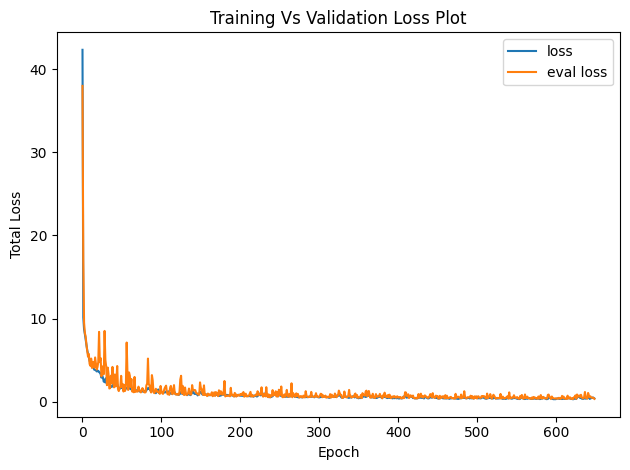

In [ ]:
plot_loss(train_loss['loss'],valid_loss['loss'], metric = 'Total Loss', title='Training Vs Validation Loss Plot')

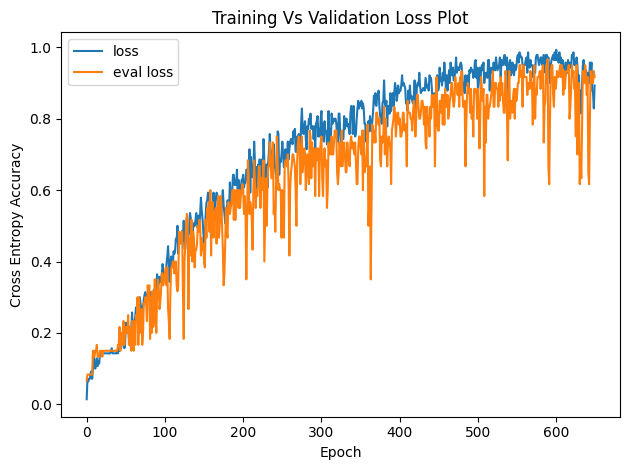

In [ ]:
plot_loss(train_loss['accuracy_ce'],valid_loss['accuracy_ce'], metric = 'Cross Entropy Accuracy', title='Training Vs Validation Loss Plot')

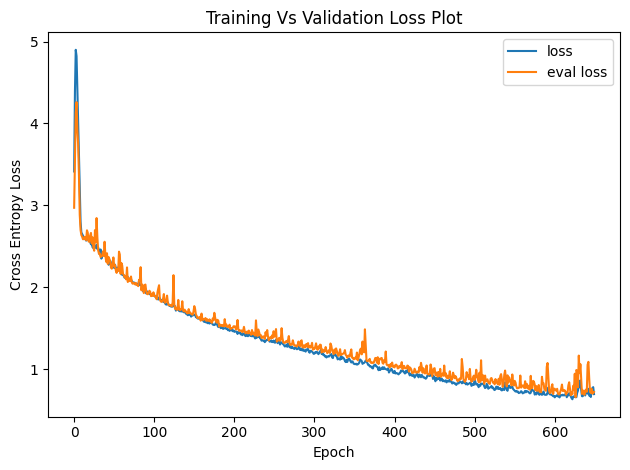

In [ ]:
plot_loss(train_loss['ce'],valid_loss['ce'], metric = 'Cross Entropy Loss', title='Training Vs Validation Loss Plot')

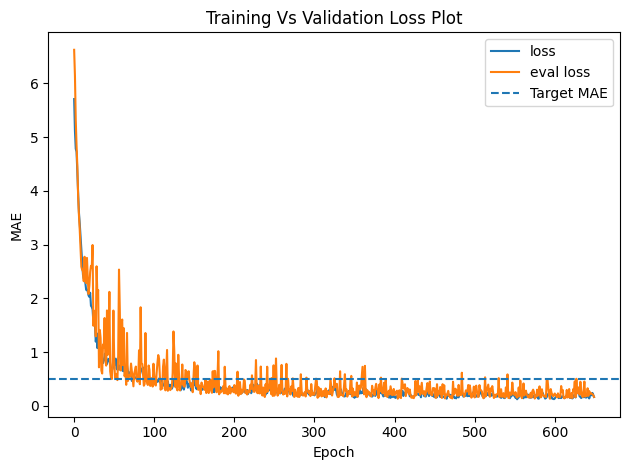

In [ ]:
plot_loss(train_loss['mae'],valid_loss['mae'], metric = 'MAE', target=EXPECTED_MAE, title='Training Vs Validation Loss Plot')

## Loading Model Checkpoints

In [ ]:
name = f'latest_checkpoint.pt'

latest_chk_path='_checkpoints/latest_checkpoint.pt'
best_chk_path='_checkpoints/best_checkpoint.pt'

#loading latest model based on last checkpoint
checkpoint = load_checkpoint(
                   latest_chk_path,
                   model,
                   device=device,
                   load_new_copy = True
                   )
if checkpoint != None:
        latest_model, _, _, _  = checkpoint
else:
     print("Loading latest checkpoint failed!")
#loading best model
checkpoint = load_checkpoint(
                   best_chk_path,
                   model,
                   device=device,
                   load_new_copy = True
                   )
if checkpoint != None:
        best_model, _, _, _  = checkpoint
else:
     print("Loading best checkpoint failed!")

Loaded checkpoint from epoch: 649
Loss: 0.377
Eval Loss: 0.330
Loaded checkpoint from epoch: 649
Loss: 0.377
Eval Loss: 0.330


In [ ]:
current_model = latest_model

## Interpretability

To understand whether the model learned meaningful signals and can generalize, I generated some of the feature maps from the CNN. The features show that the model learned transferable and meaningful filters. The feature maps show that the model detects vertical edges, which are particularly helpful for the task of predicting the number of glass sheets.

In [ ]:
def collect_feature_maps(model, image, device):
    """
    Function to generate CNN feature maps for a single image.
    """
    cnn = model.module.cnn if isinstance(model, nn.DataParallel) else model.cnn

    cnn.eval()

    #get activation at the end
    with torch.no_grad():
        x = image.unsqueeze(0).to(device)

        for layer in cnn[:-1]:
            x = layer(x)

    return x

In [ ]:
def visualize_feature_maps(
    feature_maps,
    num_maps=16,
    cols=4,
    figsize_per_map=(3, 3)
):
    """
    Function to visualize a selected number of CNN feature maps.

    feature_maps: [B, C, H, W]
    num_maps: number of feature maps to plot
    """
    maps = feature_maps[0].detach().cpu()

    # Select number of maps to plot
    num_maps = min(num_maps, maps.shape[0])

    rows = int(np.ceil(num_maps / cols))

    fig, axes = plt.subplots(
        rows,
        cols,
        figsize=(
            cols * figsize_per_map[0],
            rows * figsize_per_map[1]
        )
    )

    axes = np.asarray(axes).reshape(-1)

    for i in range(num_maps):
        axes[i].imshow(maps[i], cmap="gray")
        axes[i].set_title(f"Channel {i}", fontsize=10)
        axes[i].axis("off")

    # Hide unused axes
    for i in range(num_maps, len(axes)):
        axes[i].axis("off")

    # Tight, uniform spacing
    plt.subplots_adjust(
        left=0.01,
        right=0.99,
        bottom=0.01,
        top=0.97,
        wspace=0.05,
        hspace=0.15
    )

    plt.show()

Feature map shape: torch.Size([1, 256, 96, 72])


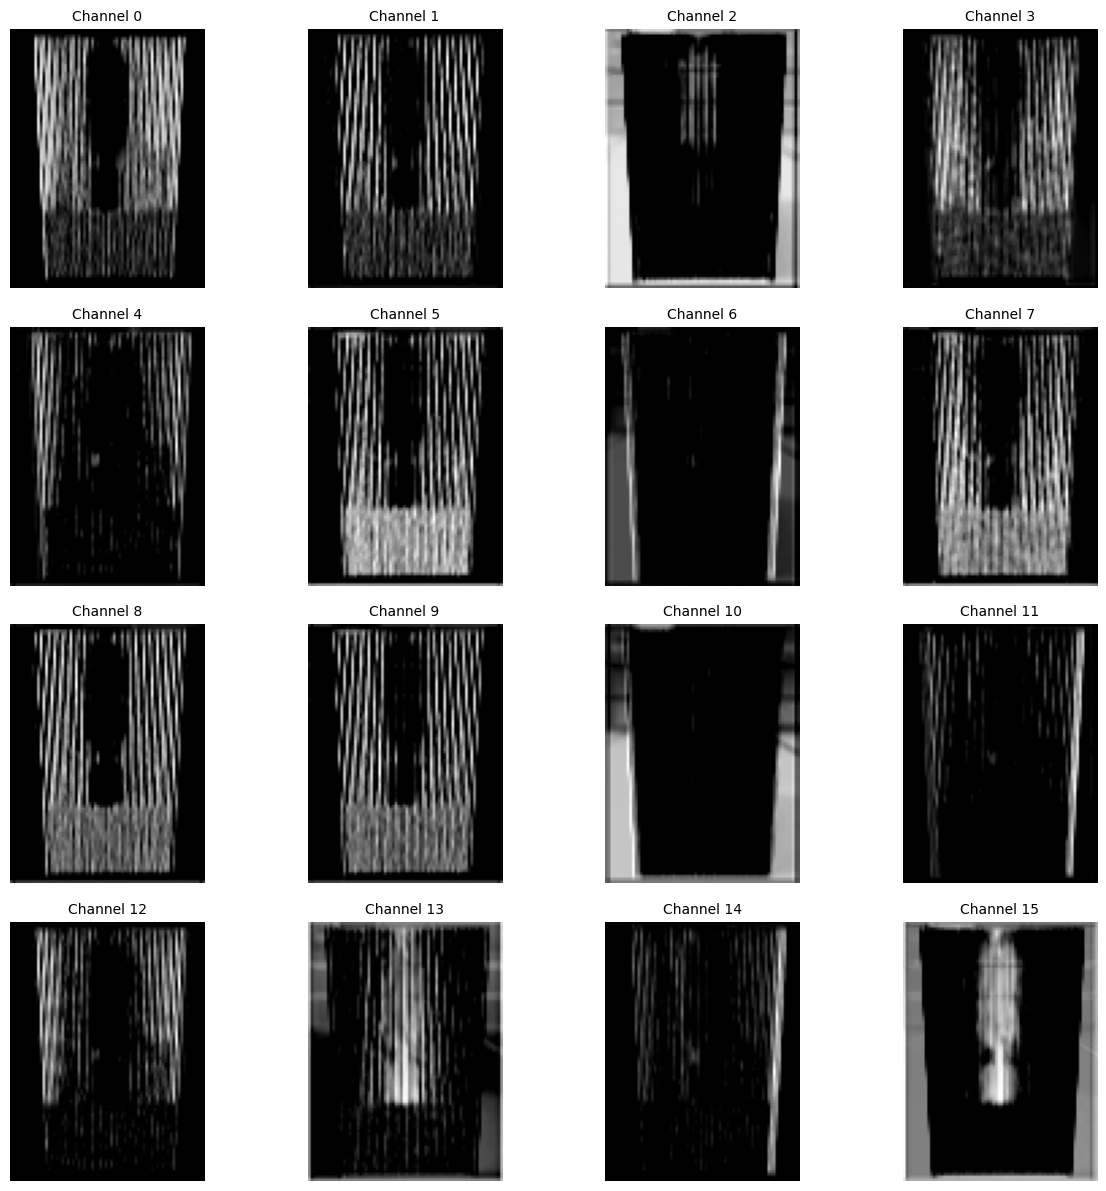

In [ ]:
image, label, features, meta = valid_dataset[0]

feature_maps = collect_feature_maps(
    current_model,
    image,
    device
)

print("Feature map shape:", feature_maps.shape)

visualize_feature_maps(
    feature_maps,
    num_maps=16
)

# PREDICTION

In [ ]:
def predict_and_save(model, data_loader,device,min_label, save_path='predictions.csv'):
      """
      Function to generate predictions from model and save to csv file.

      Returns:
             df :  Dataframe containing image number and predictions
      """
      model.to(device)
      model.eval()

      preds= []
      img_numbers = []
      with torch.no_grad():
           for batch_id, (data, targets, features, meta) in enumerate(data_loader):
                 # sending data to device if possible
                 data = data.to(device=device)


                 # [left_point, right_point, center_point, sheet_pixel_width, sheet_pixel_spacing]
                 features = features.to(device)


                 #forward pass
                 y_reg, y_class  = model(data, features) # scores for the classes

                 batch_preds = y_reg.squeeze(-1).cpu().numpy() + min_label

                 #converting the predictions to integers by rounding
                 #to the nearest integer
                 batch_preds = np.rint(batch_preds).astype(int)

                 batch_img_numbers = meta['img_number']


                 preds.extend(batch_preds.tolist())

                 img_numbers.extend(batch_img_numbers.tolist())
      #dataframe
      df = pd.DataFrame({
            'image_number': img_numbers,
              'number_of_sheets': preds

      })

      #sorting the values
      df = df.sort_values(
          by='image_number',
          ascending=True
      ).reset_index(drop=True)

      #saving to csv file
      df.to_csv(save_path, index=False)

      print(f"Predictions generated and saved to: {save_path}")

      return  df

In [ ]:
save_path  = 'output/predictions.csv'

if(os.path.exists('output/')) == False:
    os.mkdir('output/')

#making predictions and saving csv file
test_df = predict_and_save(current_model, test_loader, device, MIN_NUM, save_path)



Predictions generated and saved to: output/predictions.csv


In [ ]:
test_df.head(50)

,image_number,number_of_sheets
0,200,35
1,201,22
2,202,29
3,203,35
4,204,34
5,205,26
6,206,33
7,207,21
8,208,23
9,209,26
